<a href="https://colab.research.google.com/github/bemakerorg/AIoT_Book_II_RF/blob/main/AIOT_RF_Book_ES_27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-means Clustering for Anomaly Detection

In [1]:
# CELLA 1 - Verifica versioni librerie
import sys                        # Carica i file di sistema Python
import numpy as np                # Libreria per calcoli numerici
import sklearn                    # Libreria per machine learning
import matplotlib                 # Modulo principale di matplotlib
import matplotlib.pyplot as plt   # Libreria Interfaccia di Plotting
import seaborn as sns; sns.set()  # Importa seaborn una libreria di visualizzazione dati per creare grafici statistici

print("Versione Python:", sys.version)        # Verifica versione Python
print("NumPy:", np.__version__)               # Verifica versione NumPy
print("Scikit-learn:", sklearn.__version__)   # Verifica versione Scikit-learn
print("Matplotlib:", matplotlib.__version__)             # Verifica versione Matplotlib
print("Seaborn:", sns.__version__)            # Verifica versione seaborn

# Versioni richieste
# Qui definiamo le versioni specifiche delle librerie necessarie per garantire compatibilità e riproducibilità
np_version = "2.0.2"                  # Versione di NumPy desiderata
sklearn_version = "1.6.1"             # Versione Scikit-learn desiderata
matplotlib_version = "3.10.0"         # Versione Matplotlib desiderata
sns_version = "0.13.2"                # Versione Seaborn desiderata

# Controlliamo le versioni dei pacchetti e agiamo di conseguenza
if (np.__version__ != np_version or                   # Verifica la versione di NumPy
    sklearn.__version__ != sklearn_version or         # Verifica la versione di Scikit-learn
    matplotlib.__version__ != matplotlib_version or   # Verifica la versione di Matplotlib
    sns.__version__ != sns_version):                  # Verifica versione seaborn

    # Notifica all'utente le versioni attuali e quelle che verranno installate
    print(f"Versione NumPy corrente: {np.__version__}, switching a {np_version}")
    print(f"Versione Scikit-learn corrente: {sklearn.__version__}, switching a {sklearn_version}")
    print(f"Versione Matplotlib corrente: {matplotlib.__version__}, switching a {matplotlib_version}")
    print(f"Versione Seaborn corrente: {sns.__version__}, switching a {sns_version}")

    # Disinstalliamo le versioni correnti dei pacchetti (se necessario)
    !pip uninstall -y numpy sklearn matplotlib seaborn

    # Installiamo le versioni richieste dei pacchetti specificati
    !pip install numpy==2.0.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2

    # Informiamo l'utente che è necessario riavviare il runtime per applicare i cambiamenti
    print("Le versioni specificate delle librerie sono state installate.")
    print("Prego cliccare su Runtime > Restart session and run all.")
else:
    # Se tutte le versioni corrispondono a quelle richieste, lo segnaliamo all'utente
    print("Tutti i pacchetti sono nelle versioni specificate")


Versione Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
NumPy: 2.0.2
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Seaborn: 0.13.2
Tutti i pacchetti sono nelle versioni specificate


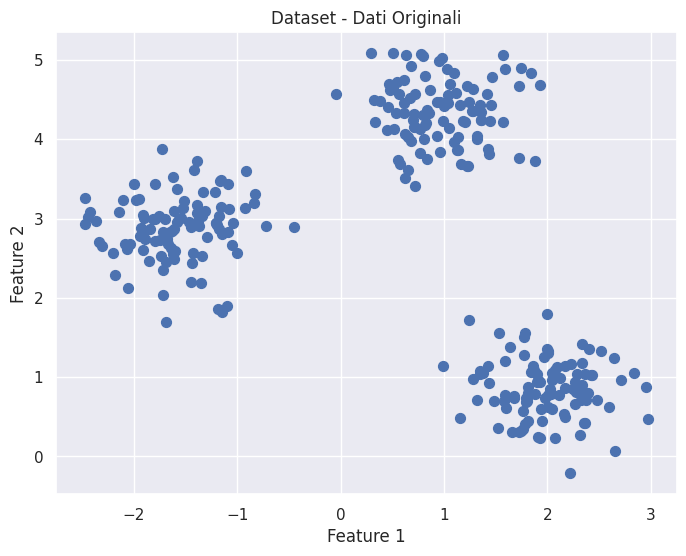

In [2]:
# Cella 2: Generazione del dataset dei dati NORMALI (facciamo generare sinteticamente i dati NORMALI)
from sklearn.datasets import make_blobs                   # Importa la funzione per generare dataset con cluster
num_centers = 3                                           # Numero di centri per i cluster
X_train, y_train_true = make_blobs(n_samples=300,         # Genera 300 campioni
                                   centers=num_centers,   # Con 3 centri
                                   cluster_std=0.40,      # Deviazione standard dei cluster
                                   random_state=0)        # Seed per riproducibilità

# Visualizzazione del dataset generato
plt.figure(figsize=(8, 6))                                # Imposta dimensioni del grafico
plt.scatter(X_train[:, 0], X_train[:, 1], s=50)           # Crea scatter plot dei punti
plt.title("Dataset - Dati Originali")                     # Titolo del grafico
plt.xlabel("Feature 1")                                   # Etichetta asse X
plt.ylabel("Feature 2")                                   # Etichetta asse Y
plt.show()                                                # Mostra il grafico

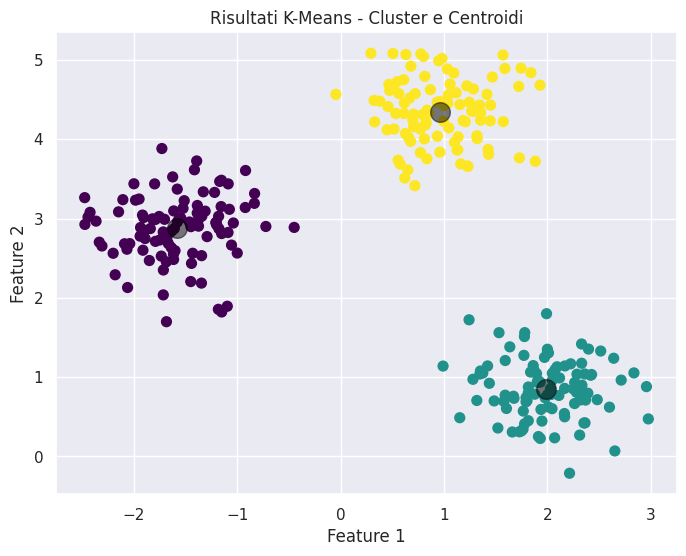

In [3]:
# Cella 3: Applicazione dell'algoritmo K-Means
from sklearn.cluster import KMeans                                          # Importa l'algoritmo K-means da scikit-learn
kmeans = KMeans(n_clusters=num_centers)                                     # Inizializza K-Means con 3 cluster
kmeans.fit(X_train)                                                         # Addestra l'algoritmo sui dati di training
y_kmeans = kmeans.predict(X_train)                                          # Predice il cluster per ogni punto

# Visualizzazione dei risultati del clustering
plt.figure(figsize=(8, 6))                                                  # Imposta dimensioni del grafico
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_kmeans, s=50, cmap='viridis') # Colora i punti per cluster

# Visualizzazione dei centroidi
centers = kmeans.cluster_centers_                                           # Ottiene le coordinate dei centroidi
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)      # Disegna i centroidi in nero
plt.title("Risultati K-Means - Cluster e Centroidi")                        # Titolo del grafico
plt.xlabel("Feature 1")                                                     # Etichetta asse X
plt.ylabel("Feature 2")                                                     # Etichetta asse Y
plt.show()                                                                  # Mostra il grafico

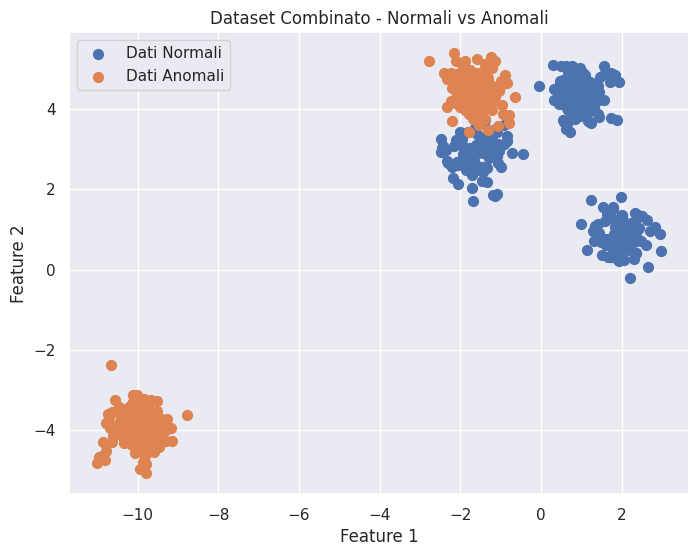

In [4]:
# Cella 4: Generazione di un dataset anomalo per test
X_anomaly, y_anomaly_true = make_blobs(n_samples=300,     # Genera 300 campioni anomali
                                       centers=2,         # Con 2 centri diversi
                                       cluster_std=0.40,  # Stessa deviazione standard
                                       random_state=1)    # Seed diverso per variabilità

# Visualizzazione combinata dei dataset
plt.figure(figsize=(8, 6))                                                  # Imposta dimensioni del grafico
plt.scatter(X_train[:, 0], X_train[:, 1], s=50, label='Dati Normali')       # Punti normali
plt.scatter(X_anomaly[:, 0], X_anomaly[:, 1], s=50, label='Dati Anomali')   # Punti anomali
plt.title("Dataset Combinato - Normali vs Anomali")                         # Titolo del grafico
plt.xlabel("Feature 1")                                                     # Etichetta asse X
plt.ylabel("Feature 2")                                                     # Etichetta asse Y
plt.legend()                                                                # Mostra la legenda
plt.show()                                                                  # Mostra il grafico

In [5]:
# Cella 5: Calcolo delle soglie per il rilevamento delle anomalie
percentile_treshold = 99                                            # Soglia del 99° percentile per definire le anomalie

# Calcolo delle distanze dei punti di training (punti normali) dai centroidi
train_distances = kmeans.transform(X_train)                         # Matrice delle distanze da tutti i centroidi

# Raggruppamento delle distanze per cluster
center_distances = {key: [] for key in range(num_centers)}          # Raccolta delle distanze per ogni cluster
for i in range(len(y_kmeans)):                                      # Per ogni punto di training
    min_distance = train_distances[i][y_kmeans[i]]                  # Distanza dal centroide assegnato
    center_distances[y_kmeans[i]].append(min_distance)              # Aggiunge al cluster corrispondente

# Calcolo del 99° percentile per ogni cluster
center_99percentile_distance = {key: np.percentile(center_distances[key], percentile_treshold)
                               for key in center_distances.keys()}  # Soglia per cluster

print("Soglie del 99° percentile per cluster:")                     # Stampa le soglie
print(center_99percentile_distance)                                 # Mostra i valori calcolati

Soglie del 99° percentile per cluster:
{0: np.float64(1.1415867080723232), 1: np.float64(1.0917976541677417), 2: np.float64(1.0315363528478958)}


Ora tracciamo un grafico di questi limiti normali/anomali sui nostri dati di allenamento per vedere quanto bene li comprendono. Tracceremo anche in giallo i punti nei nostri dati di allenamento che vengono classificati come anomali.

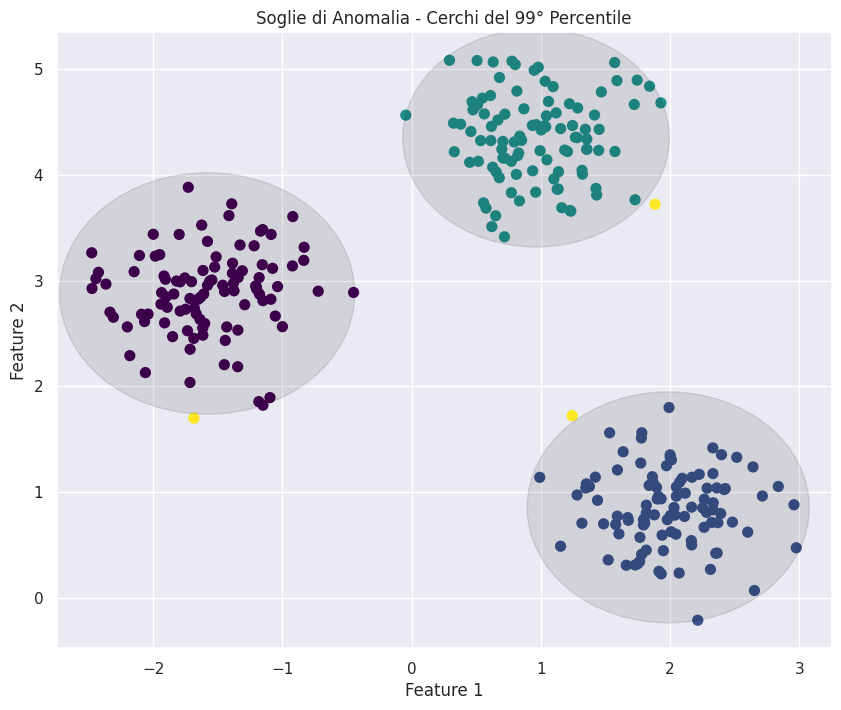

In [6]:
# Cella 6: Visualizzazione delle soglie di anomalia sui dati di training
fig, ax = plt.subplots(figsize=(10, 8))                                   # Crea figura con subplot

colors = []                                                               # Lista per i colori dei punti
for i in range(len(X_train)):                                             # Per ogni punto di training
    min_distance = train_distances[i][y_kmeans[i]]                        # Distanza dal centroide assegnato
    if (min_distance > center_99percentile_distance[y_kmeans[i]]):        # Se supera la soglia
        colors.append(4)                                                  # Colore per anomalia
    else:
        colors.append(y_kmeans[i])                                        # Colore del cluster originale

# Visualizzazione dei punti con classificazione anomalia
ax.scatter(X_train[:, 0], X_train[:, 1], c=colors, s=50, cmap='viridis')  # Scatter plot

# Disegno delle soglie come cerchi
for i in range(len(centers)):                                             # Per ogni centroide
    circle = plt.Circle((centers[i][0], centers[i][1]),                   # Centro del cerchio
                       center_99percentile_distance[i],                   # Raggio = soglia percentile
                       color='black', alpha=0.1)                          # Cerchio trasparente nero
    ax.add_artist(circle)                                                 # Aggiunge il cerchio al grafico

ax.set_title("Soglie di Anomalia - Cerchi del 99° Percentile")            # Titolo
ax.set_xlabel("Feature 1")                                                # Etichetta asse X
ax.set_ylabel("Feature 2")                                                # Etichetta asse Y
plt.show()                                                                # Mostra il grafico

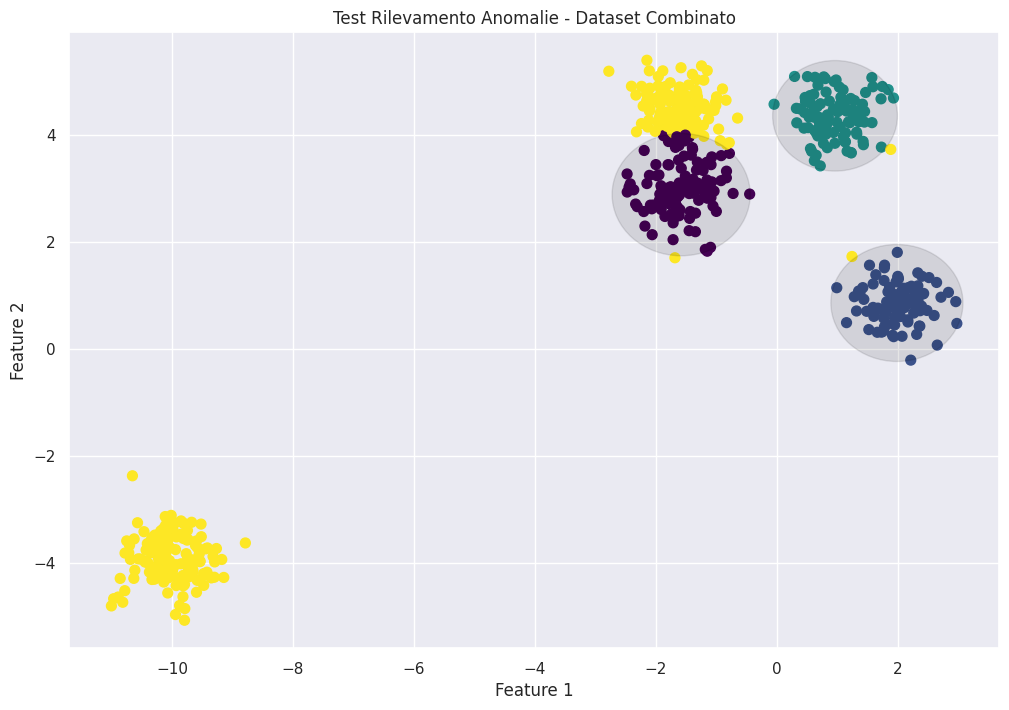

Punti normali classificati erroneamente come anomali: 3
Punti anomali classificati erroneamente come normali: 17


In [7]:
# Cella 7: Test del sistema di rilevamento anomalie
fig, ax = plt.subplots(figsize=(12, 8))                                   # Crea figura più grande

# Predizione sui dati anomali
anomaly_distances = kmeans.transform(X_anomaly)                           # Calcola distanze dati anomali
y_anomaly = kmeans.predict(X_anomaly)                                     # Assegna cluster ai dati anomali

# Combinazione di tutti i dati
combined_distances = [*train_distances, *anomaly_distances]               # Unisce le distanze
combined_y = [*y_kmeans, *y_anomaly]                                      # Unisce le etichette cluster
all_data = np.array([*X_train, *X_anomaly])                               # Unisce tutti i punti

# Contatori per errori di classificazione
false_neg = 0                                                             # Falsi negativi (anomalie non rilevate)
false_pos = 0                                                             # Falsi positivi (normali classificati come anomali)

colors = []                                                               # Lista colori per visualizzazione
for i in range(len(all_data)):                                            # Per ogni punto del dataset combinato
    min_distance = combined_distances[i][combined_y[i]]  # Distanza dal centroide
    if (min_distance > center_99percentile_distance[combined_y[i]]):  # Se supera soglia
        colors.append(4)  # Colore anomalia
        if (i < 300):  # Se è un punto di training (primi 300)
            false_pos += 1  # Incrementa falsi positivi
    else:
        colors.append(combined_y[i])  # Colore cluster normale
        if (i >= 300):  # Se è un punto anomalo (dopo elemento 300)
            false_neg += 1  # Incrementa falsi negativi

# Visualizzazione risultati
ax.scatter(all_data[:, 0], all_data[:, 1], c=colors, s=50, cmap='viridis')  # Scatter plot

# Disegno cerchi soglia
for i in range(len(centers)):  # Per ogni centroide
    circle = plt.Circle((centers[i][0], centers[i][1]),  # Centro cerchio
                       center_99percentile_distance[i],  # Raggio soglia
                       color='black', alpha=0.1)  # Cerchio trasparente
    ax.add_artist(circle)  # Aggiunge cerchio

ax.set_title("Test Rilevamento Anomalie - Dataset Combinato")  # Titolo
ax.set_xlabel("Feature 1")  # Etichetta asse X
ax.set_ylabel("Feature 2")  # Etichetta asse Y
plt.show()  # Mostra grafico

# Stampa risultati performance
print('Punti normali classificati erroneamente come anomali:', false_pos)
print('Punti anomali classificati erroneamente come normali:', false_neg)